# I - Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import tqdm  
import seaborn as sns

# II - Đọc dữ liệu từ file CSV

In [2]:
data = pd.read_csv("./data/data-commerce.csv") 
print(data.shape)

(42448764, 9)


In [3]:
print(data.head())

                event_time event_type  product_id          category_id  \
0  2019-10-01 00:00:00 UTC       view    44600062  2103807459595387724   
1  2019-10-01 00:00:00 UTC       view     3900821  2053013552326770905   
2  2019-10-01 00:00:01 UTC       view    17200506  2053013559792632471   
3  2019-10-01 00:00:01 UTC       view     1307067  2053013558920217191   
4  2019-10-01 00:00:04 UTC       view     1004237  2053013555631882655   

                         category_code     brand    price    user_id  \
0                                  NaN  shiseido    35.79  541312140   
1  appliances.environment.water_heater      aqua    33.20  554748717   
2           furniture.living_room.sofa       NaN   543.10  519107250   
3                   computers.notebook    lenovo   251.74  550050854   
4               electronics.smartphone     apple  1081.98  535871217   

                           user_session  
0  72d76fde-8bb3-4e00-8c23-a032dfed738c  
1  9333dfbd-b87a-4708-9857-6336556b0fc

# III - Tiền xử lý dữ liệu

#### Tiến hành loại bỏ các hàng có giá trị missing value : 

In [ ]:
data = pd.read_csv("./data/data-commerce.csv")
data_clean = data.dropna().reset_index(drop=True)
data_clean.to_csv("./data/data-commerce-clean.csv", index=False)

In [2]:
data_clean = pd.read_csv("./data/data-commerce-clean.csv")

# III - Phân Tích Khai Phá Dữ Liệu

#### 3.1 - Phân bố các loại event trong dữ liệu e-commerce

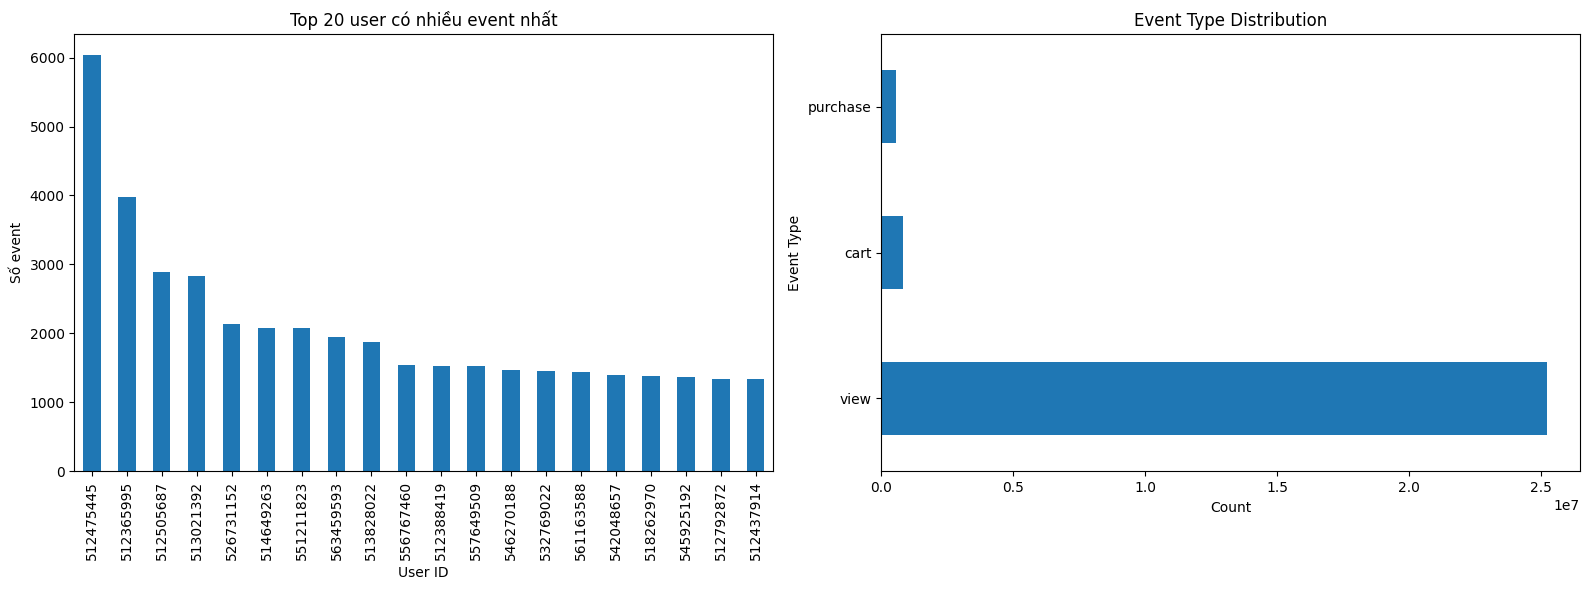

event_type,view,cart,purchase
count,25201706.00,809407.00,549507.00
ratio,0.95,0.03,0.02


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

data_clean["user_id"].value_counts().head(20).plot(kind="bar", ax=axes[0])
axes[0].set_title("Top 20 user có nhiều event nhất")
axes[0].set_xlabel("User ID")
axes[0].set_ylabel("Số event")

ET = data_clean["event_type"].value_counts().to_frame()
ET.columns = ["count"]
ET["ratio"] = (ET["count"] / data_clean.shape[0]).round(2)

ET["count"].plot(kind="barh", ax=axes[1])
axes[1].set_title("Event Type Distribution")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Event Type")

plt.tight_layout()
plt.show()

display(ET.T.style.format("{:.2f}").set_caption("Count and Ratio of Event Types"))

#### Phân phối giá sản phẩm 

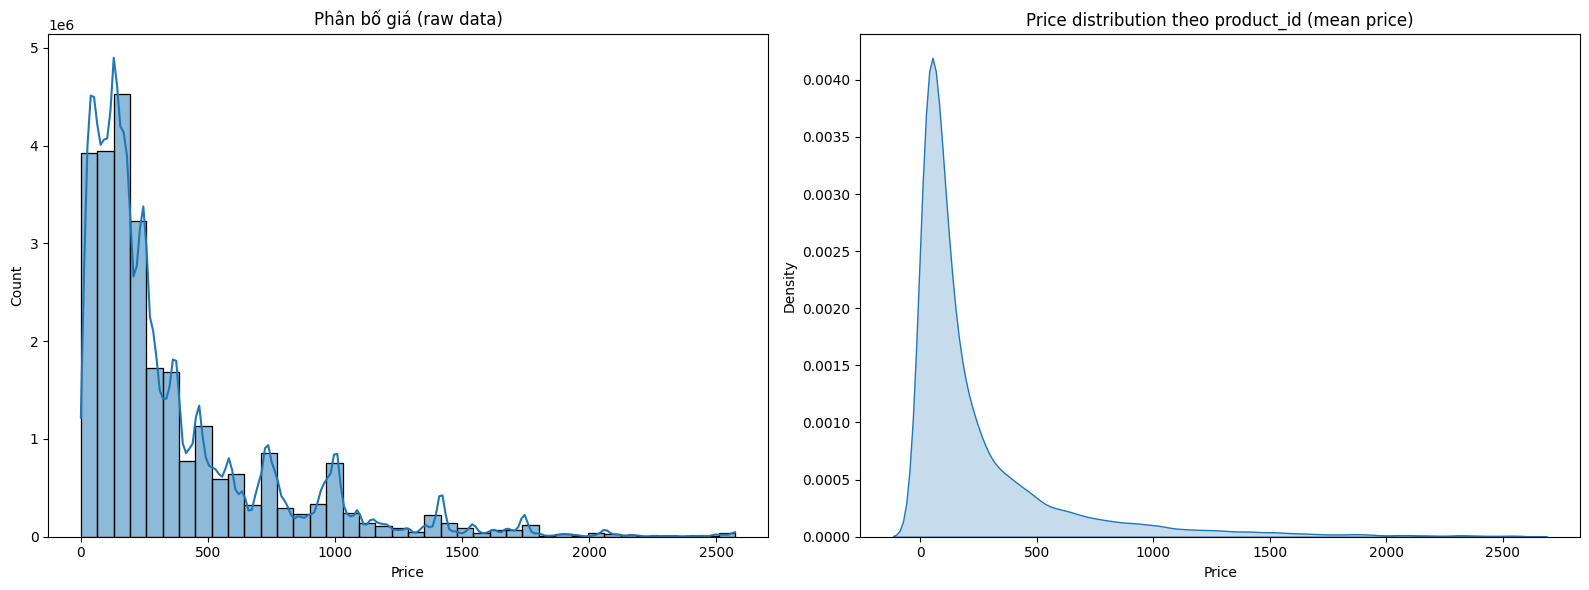

In [4]:
data_clean["price"] = pd.to_numeric(data_clean["price"], errors="coerce")

products = data_clean.groupby("product_id").agg(
    {"category_code": "first", "brand": "first", "price": "mean"}
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data_clean["price"].dropna(), bins=40, kde=True, ax=axes[0])
axes[0].set_title("Phân bố giá (raw data)")
axes[0].set_xlabel("Price")

sns.kdeplot(x=products["price"].dropna(), fill=True, ax=axes[1])
axes[1].set_title("Price distribution theo product_id (mean price)")
axes[1].set_xlabel("Price")

plt.tight_layout()
plt.show()

#### Phân bố giá và số lượng sản phẩm giữa 5 danh mục phổ biến nhất trong tập dataset: 

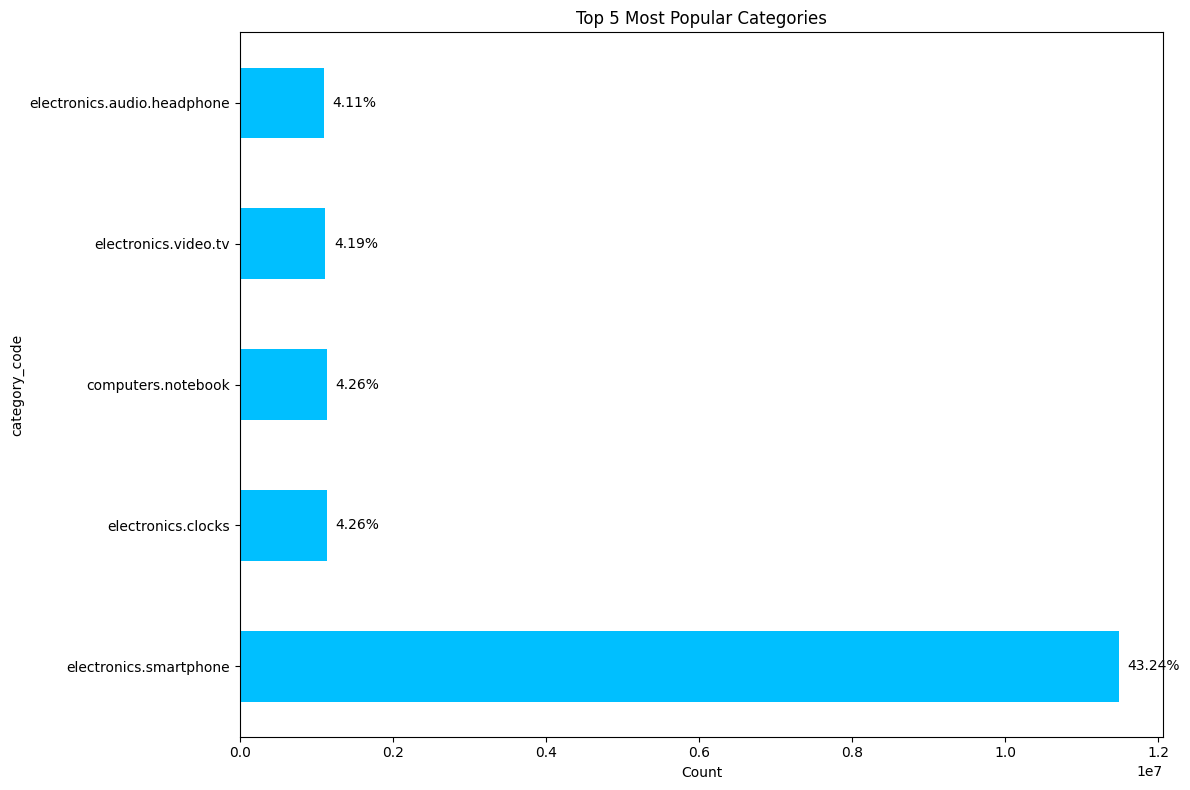

category_code,electronics.smartphone,electronics.clocks,computers.notebook,electronics.video.tv,electronics.audio.headphone
count,11485320.00,1132207.00,1131269.00,1112047.00,1092952.00
ratio,43.24,4.26,4.26,4.19,4.11


category_code,electronics.clocks,electronics.audio.headphone,computers.notebook,electronics.smartphone,electronics.video.tv
count,5377,2012,1323,1281,550


C:\Users\NGUYEN GIA KHANH\AppData\Local\Temp\ipykernel_27664\2284935308.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
C:\Users\NGUYEN GIA KHANH\AppData\Local\Temp\ipykernel_27664\2284935308.py:41: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  g = sns.catplot(


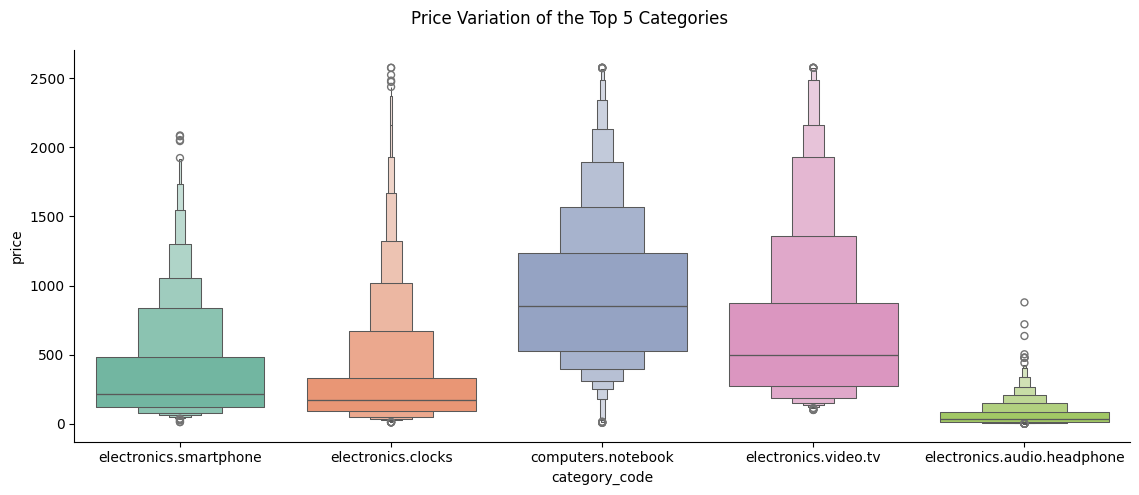

In [11]:
popular_categories = data_clean["category_code"].value_counts().to_frame()
popular_categories.columns = ["count"]
popular_categories["ratio"] = np.round(
    popular_categories["count"] / data_clean.shape[0] * 100, 2
)

top5_df = popular_categories.head(5)

plt.figure(figsize=(12, 8))
ax = top5_df["count"].plot(kind="barh", color="deepskyblue")
plt.title("Top 5 Most Popular Categories")
plt.xlabel("Count")


for i, (count, ratio) in enumerate(zip(top5_df["count"], top5_df["ratio"])):
    ax.text(
        count + max(top5_df["count"]) * 0.01,
        i,  
        f"{ratio}%",  
        va="center",
    )

plt.tight_layout()
plt.show()

display(
    top5_df.T.style.format("{:.2f}").set_caption("Top 5 Most popular categories (%)")
)

top_categories = top5_df.index.tolist()
top5 = products[products["category_code"].isin(top_categories)]

display(
    top5["category_code"]
    .value_counts()
    .to_frame()
    .T.style.set_caption("Number of items per top 5 category")
)

palette = sns.color_palette("Set2")
g = sns.catplot(
    data=top5,
    x="category_code",
    y="price",
    kind="boxen",
    aspect=2.3,
    order=top_categories,
    palette=palette, 
    color="blue"
)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Price Variation of the Top 5 Categories")
plt.show()

#### Phân tích tổng quan số lượng và phân bố giá của các thương hiệu:

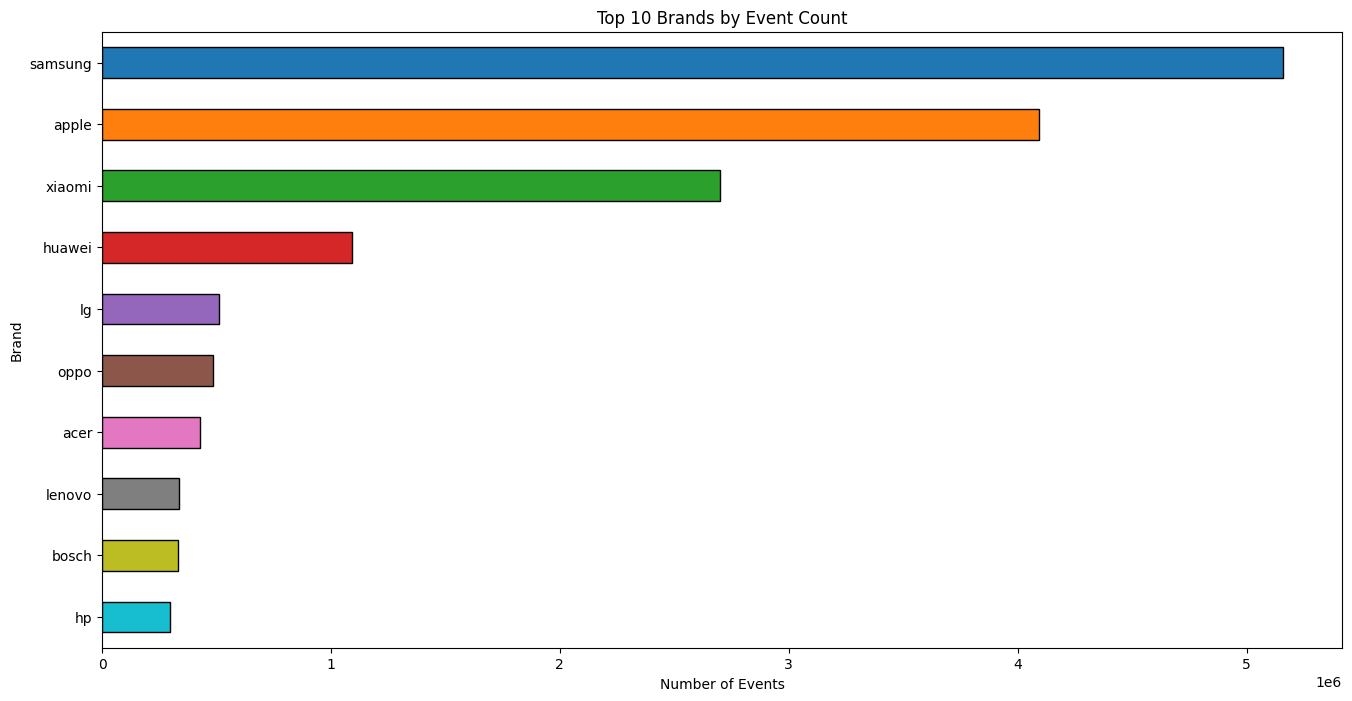

brand,samsung,apple,xiaomi,huawei,lg,oppo,acer,lenovo,bosch,hp
count,5158902.00,4092652.00,2697644.00,1092346.00,508999.00,482887.00,428081.00,337970.00,329835.00,295026.00
ratio,0.19,0.15,0.10,0.04,0.02,0.02,0.02,0.01,0.01,0.01


C:\Users\NGUYEN GIA KHANH\AppData\Local\Temp\ipykernel_27664\3950178486.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


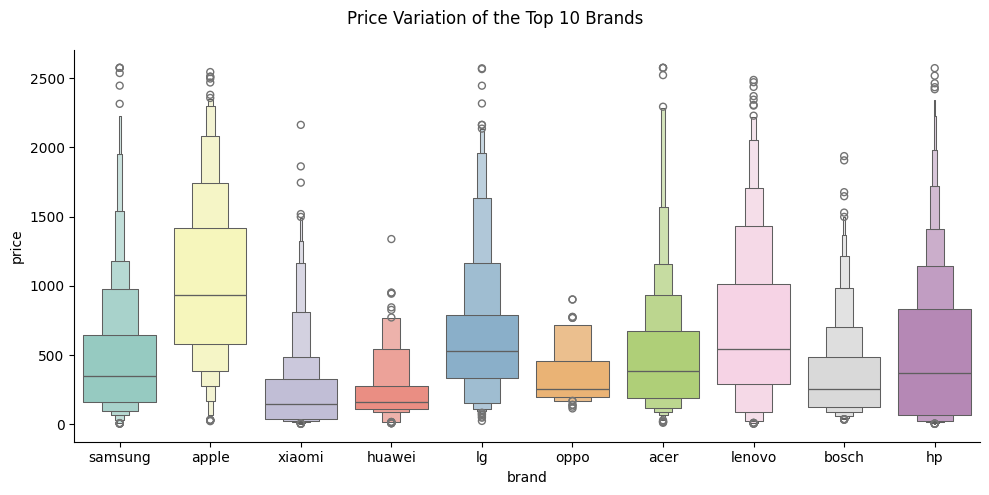

In [12]:
B = data_clean["brand"].value_counts().to_frame()
B.columns = ["count"]
B["ratio"] = np.round(B["count"] / data_clean.shape[0], 2)

top_brands = B.head(10).index.tolist()
top10_df = products[products["brand"].isin(top_brands)]

f, ax = plt.subplots(1, figsize=(16, 8))
colors = sns.color_palette("tab10", 10)
B.loc[top_brands, "count"].plot(kind="barh", ax=ax, color=colors, edgecolor="black")
ax.set_title("Top 10 Brands by Event Count")
ax.set_xlabel("Number of Events")
ax.set_ylabel("Brand")
plt.gca().invert_yaxis()  
plt.show()

display(
    B.loc[top_brands].T.style.format("{:.2f}").set_caption("Top 10 Brands by Ratio")
)

g = sns.catplot(
    data=top10_df,
    x="brand",
    y="price",
    kind="boxen",
    aspect=2.0,
    order=top_brands,
    palette="Set3",
)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Price Variation of the Top 10 Brands")
plt.show()

In [7]:
import pandas as pd
import numpy as np

# Đọc lại data clean (nếu chưa load)
data_clean = pd.read_csv("./data/data-commerce-clean.csv")

# Top 10 brands theo số lượng event
B = data_clean["brand"].value_counts().to_frame(name="count")
B["ratio (%)"] = np.round(B["count"] / len(data_clean) * 100, 1)

top_brands = B.head(10).index.tolist()
print("Top 10 brands:", top_brands)

# Conversion rate (% purchase trong tổng event của brand đó)
conversion_rate = (
    data_clean.groupby("brand")["event_type"]
    .apply(lambda x: (x == "purchase").mean() * 100)
    .round(2)
)
top10_conversion = conversion_rate.loc[top_brands].sort_values(ascending=False)

# Doanh thu từ purchase
purchase_data = data_clean[data_clean["event_type"] == "purchase"]
revenue = purchase_data.groupby("brand")["price"].sum()

top10_revenue = revenue.loc[top_brands]

# Bảng tổng hợp ĐẸP (đã sửa lỗi cú pháp)
summary = pd.DataFrame(
    {
        "Event Share (%)": B.loc[top_brands, "ratio (%)"],
        "Conversion Rate (%)": top10_conversion.values,  # .values để align đúng thứ tự
        "Revenue (USD)": top10_revenue.values,
        "Revenue (triệu USD)": np.round(top10_revenue.values / 1_000_000, 2),
    },
    index=top_brands,
)  # đặt index là tên brand cho đẹp

summary = summary.sort_values("Revenue (USD)", ascending=False)

# Định dạng đẹp
summary_styled = summary.style.format(
    {
        "Event Share (%)": "{:.1f}",
        "Conversion Rate (%)": "{:.2f}%",
        "Revenue (USD)": "${:,.0f}",
        "Revenue (triệu USD)": "{:.2f}",
    }
).background_gradient(cmap="viridis", subset=["Revenue (triệu USD)"])

display(summary_styled)

Top 10 brands: ['samsung', 'apple', 'xiaomi', 'huawei', 'lg', 'oppo', 'acer', 'lenovo', 'bosch', 'hp']


,Event Share (%),Conversion Rate (%),Revenue (USD),Revenue (triệu USD)
apple,15.4,3.33%,"$111,189,822",111.19
samsung,19.4,3.48%,"$46,350,826",46.35
xiaomi,10.2,2.26%,"$8,869,392",8.87
huawei,4.1,2.13%,"$4,872,030",4.87
acer,1.6,1.54%,"$3,576,720",3.58
lg,1.9,1.73%,"$3,225,785",3.23
oppo,1.8,1.61%,"$2,412,960",2.41
lenovo,1.3,1.35%,"$1,752,639",1.75
hp,1.1,1.16%,"$1,217,211",1.22
bosch,1.2,1.23%,"$870,727",0.87
